# 10 — Evaluation & Comparison (LLM-as-a-Judge Ground Truth Match)
**Project:** Semantic Book Recommender — IT4142 HUST
**Input:**
- `data/processed/books_with_emotions.csv`
- `data/eval/qrels.json` (TREC-style ground truth with multi-relevance)
- All model and index artifacts (`models/`, `data/chroma_db/`)

**Output:**
- `reports/evaluation_final.json` — Precision@5, Recall@5, MRR, NDCG@10, and MAP metrics
- `reports/figures/eval_precision_bar.png`
- `reports/figures/eval_latency_quality.png`

## 1. Khởi tạo & Định nghĩa Đường dẫn

In [9]:
import os
from pathlib import Path
import sys

# Auto-adjust working directory to 'AI' if running from the root workspace
cwd = Path(os.getcwd())
if (cwd / 'AI').exists() and not (cwd / 'src').exists():
    os.chdir(cwd / 'AI')
    print(f"Adjusted working directory to: {os.getcwd()}")
else:
    print(f"Current working directory: {os.getcwd()}")

import pandas as pd
import numpy as np
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Ensure src is importable
sys.path.insert(0, str(Path(os.getcwd())))

from src.config.settings import get_settings
from src.retrieval.tfidf_retriever import TFIDFRetriever
from src.retrieval.bm25_retriever import BM25Retriever
from src.retrieval.dense_retriever import DenseRetriever
from src.retrieval.hybrid_rrf_retriever import HybridRRFRetriever
from src.retrieval.rerank_retriever import RerankRetriever
from src.evaluation.evaluator import Evaluator
from src.pipelines.evaluate_retrievers import load_dataframe, load_qrels

settings = get_settings()
settings.dataset_path = "data/processed/books_with_emotions.csv"

REPORT_PATH  = Path('reports')
FIGURE_PATH  = Path('reports/figures')

REPORT_PATH.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

# Matplotlib style setup
plt.rcParams.update({
    'figure.dpi': 150, 
    'savefig.dpi': 150,
    'figure.facecolor': 'white', 
    'axes.facecolor': '#F9F9F9',
    'axes.spines.top': False, 
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13, 
    'axes.labelsize': 11,
})

MODEL_COLORS = {
    'TF-IDF':   '#6B8CBA',
    'BM25':     '#F4A261',
    'Semantic': '#2A9D8F',
    'Hybrid':   '#E76F51',
    'Reranking':'#8338EC',
}

Current working directory: /Users/taduylam/Workspace/IT4930/AI


## 2. Load Dữ liệu & Nhãn Đánh giá (qrels.json)

In [10]:
print("Loading dataset using modular loader...")
df = load_dataframe(settings)
print(f"✓ Books loaded: {len(df):,}")

qrels_path = Path(settings.eval_output_path) / "qrels_long_only.json"
qrels = load_qrels(qrels_path)
print(f"✓ Test queries loaded from qrels: {len(qrels)}")

Loading dataset using modular loader...
✓ Books loaded: 500
✓ Test queries loaded from qrels: 104


## 3. Tải toàn bộ Model & Index

In [11]:
settings.tfidf_model_path = Path('models/tfidf_vectorizer.pkl')
settings.bm25_index_path = Path('models/bm25_index.pkl')

print("Loading TF-IDF...")
tfidf = TFIDFRetriever.load(
    model_path=Path(settings.tfidf_model_path),
    matrix_path=Path(settings.tfidf_matrix_path),
    df=df,
)

print("Loading BM25...")
bm25 = BM25Retriever.load(
    index_path=Path(settings.bm25_index_path),
    df=df,
)

print("Loading Dense (ChromaDB)...")
dense = DenseRetriever.load(
    chroma_path=Path(settings.chroma_path),
    embedding_model=settings.embedding_model,
    collection_name=settings.chroma_collection_name,
)

print("Loading Hybrid RRF...")
hybrid = HybridRRFRetriever(
    bm25_retriever=bm25,
    dense_retriever=dense,
    candidate_pool=settings.hybrid_candidate_pool,
    rrf_k=settings.rrf_k,
)

print("Loading Reranker...")
rerank = RerankRetriever(
    dense_retriever=dense,
    rerank_model=settings.rerank_model,
    candidate_pool=settings.rerank_candidate_pool,
)

retrievers = {
    "TF-IDF": tfidf,
    "BM25": bm25,
    "Semantic": dense,
    "Hybrid": hybrid,
    "Reranking": rerank,
}
print("\nAll modular retrievers loaded successfully! ✓")

Loading TF-IDF...
Loading BM25...
Loading Dense (ChromaDB)...
Loading Hybrid RRF...
Loading Reranker...

All modular retrievers loaded successfully! ✓


## 4. Chạy Đánh giá Hệ thống (Evaluator Flow)

In [12]:
# Khởi tạo evaluator với đầy đủ các tham số bắt buộc
# Evaluator.__init__ yêu cầu 3 tham số:
#   1. retrievers (dict): mapping tên retriever -> instance BaseRetriever
#   2. qrels (list): list các QrelItem (ground-truth relevance judgments)
#   3. settings: cấu hình ứng dụng chứa eval_top_k, eval_output_path, etc.

print("Khởi tạo Evaluator với các retrievers, qrels, và settings...")
evaluator = Evaluator(retrievers=retrievers, qrels=qrels, settings=settings)

print("Bắt đầu đánh giá các retrievers...")
print("Đánh giá sẽ mất vài phút tùy vào kích thước dữ liệu và tốc độ hệ thống.")
print()

# Chạy evaluator trên tất cả các retrievers cùng một lúc
# Evaluator.run() thực hiện:
#   1. Loop qua từng retriever trong self._retrievers
#   2. Với mỗi retriever, loop qua từng query trong qrels
#   3. Chạy retriever.search(query, top_k)
#   4. Tính toán IR metrics (P@5, P@10, R@5, R@10, MRR, NDCG@10, MAP)
#   5. Macro-average metrics qua tất cả queries
#   6. Lưu results tới evaluation_results.json
#
# Trả về: EvalSummary chứa results[retriever_name] = BenchmarkResult per retriever

eval_summary = evaluator.run()

print()
print("✓ Đánh giá hoàn thành!")
print(f"✓ Evaluation results lưu tại: {Path(settings.eval_output_path) / 'evaluation_results.json'}")

Khởi tạo Evaluator với các retrievers, qrels, và settings...
Bắt đầu đánh giá các retrievers...
Đánh giá sẽ mất vài phút tùy vào kích thước dữ liệu và tốc độ hệ thống.



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


✓ Đánh giá hoàn thành!
✓ Evaluation results lưu tại: data/eval/evaluation_results.json


## 5. Kết quả Đánh giá & Báo cáo so sánh

In [13]:
# Trích xuất kết quả từ EvalSummary
# eval_summary.results là dict[str, BenchmarkResult]
# Mỗi BenchmarkResult chứa:
#   - retriever_name, precision_at_5, precision_at_10, recall_at_5, recall_at_10
#   - mrr, ndcg_at_10, map_score, num_queries, latency_ms

results_dict = {}
for retriever_name, benchmark_result in eval_summary.results.items():
    results_dict[retriever_name] = {
        "P@5": benchmark_result.precision_at_5,
        "P@10": benchmark_result.precision_at_10,
        "R@5": benchmark_result.recall_at_5,
        "R@10": benchmark_result.recall_at_10,
        "MRR": benchmark_result.mrr,
        "NDCG@10": benchmark_result.ndcg_at_10,
        "MAP": benchmark_result.map_score,
        "Latency (ms)": benchmark_result.latency_ms,
    }

# Tạo DataFrame so sánh kết quả
summary_df = pd.DataFrame(results_dict).T
summary_df.index.name = "Model"

print("\n" + "="*80)
print("FINAL EVALUATION RESULTS SUMMARY")
print("="*80)
display(summary_df)

# In ra thống kê tóm tắt
print("\nTop performers:")
print(f"Highest MRR: {summary_df['MRR'].idxmax()} ({summary_df['MRR'].max():.4f})")
print(f"Highest NDCG@10: {summary_df['NDCG@10'].idxmax()} ({summary_df['NDCG@10'].max():.4f})")
print(f"Highest MAP: {summary_df['MAP'].idxmax()} ({summary_df['MAP'].max():.4f})")
print(f"Fastest Latency: {summary_df['Latency (ms)'].idxmin()} ({summary_df['Latency (ms)'].min():.2f} ms)")


FINAL EVALUATION RESULTS SUMMARY


,P@5,P@10,R@5,R@10,MRR,NDCG@10,MAP,Latency (ms)
Model,,,,,,,,
TF-IDF,0.186538,0.118269,0.334178,0.372814,0.651854,0.400455,0.304862,4.375586
BM25,0.142308,0.086538,0.275652,0.296789,0.520185,0.315739,0.242619,17.617913
Semantic,0.096154,0.056731,0.197275,0.230610,0.409837,0.234016,0.177377,72.095363
Hybrid,0.159615,0.090385,0.305185,0.343876,0.616186,0.362949,0.277416,36.351244
Reranking,0.100000,0.054808,0.232527,0.236627,0.421982,0.254486,0.204777,2859.705436



Top performers:
Highest MRR: TF-IDF (0.6519)
Highest NDCG@10: TF-IDF (0.4005)
Highest MAP: TF-IDF (0.3049)
Fastest Latency: TF-IDF (4.38 ms)


## 6. Trực quan hóa Biểu đồ So sánh hiệu năng

✓ Saved: reports/figures/eval_precision_bar.png


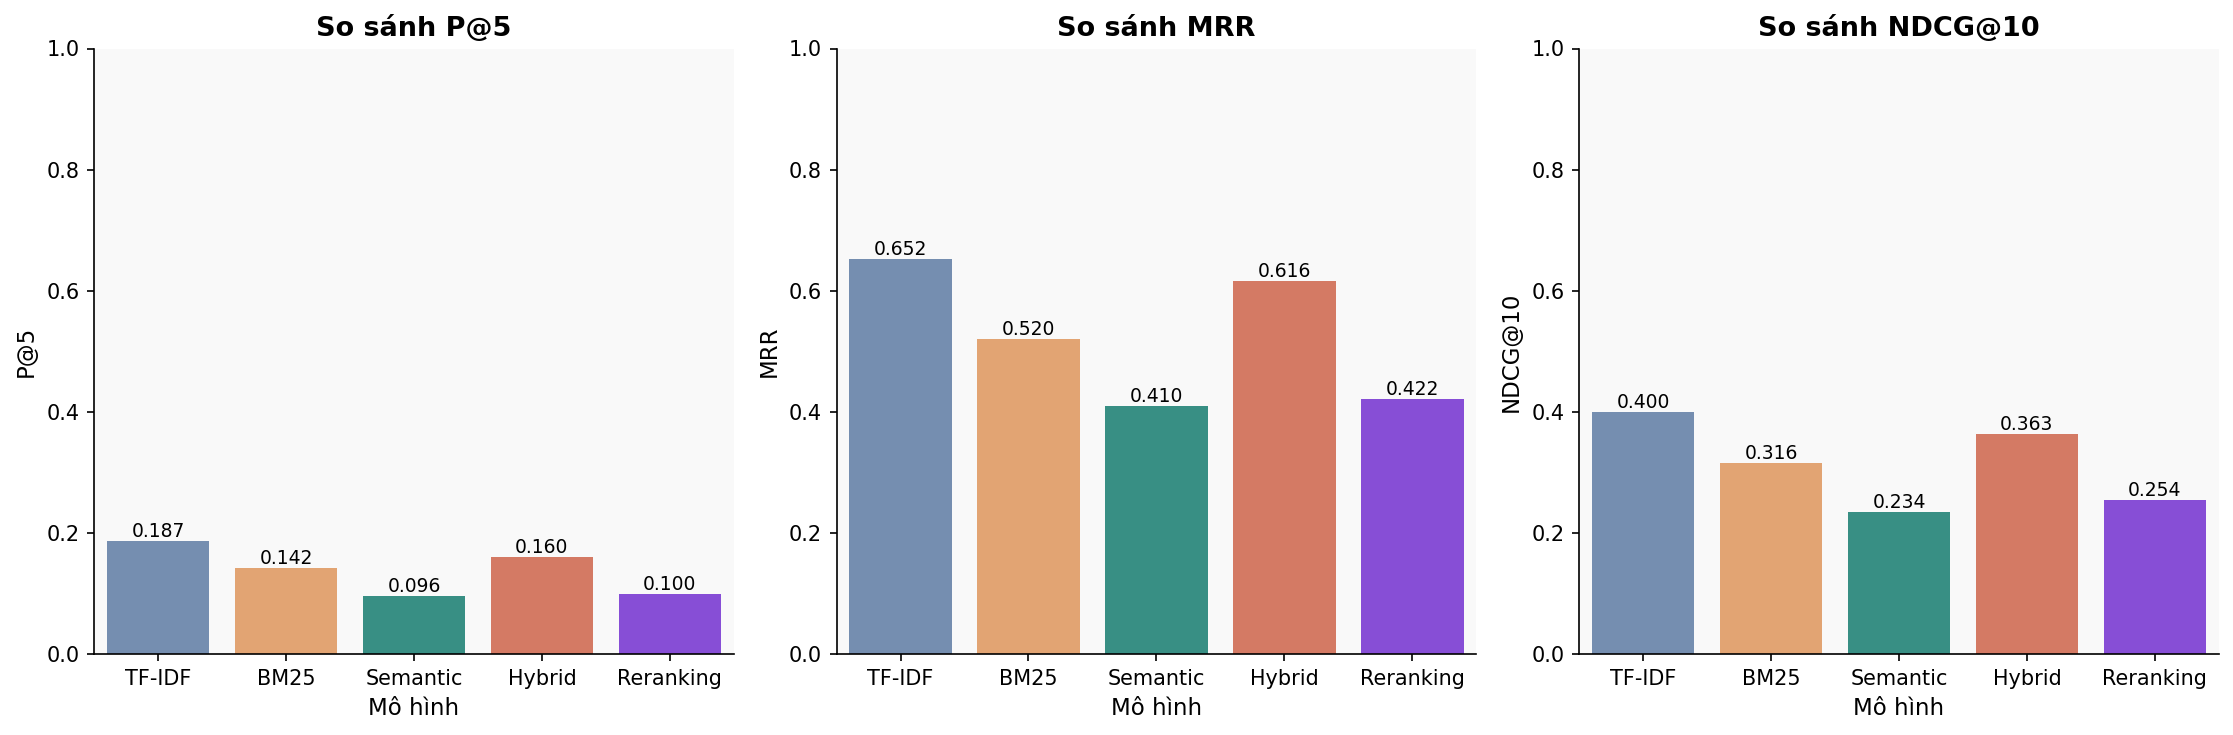

In [14]:
# 1. Biểu đồ so sánh Precision@5, MRR, và NDCG@10 giữa các mô hình
metrics_to_plot = ["P@5", "MRR", "NDCG@10"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(metrics_to_plot):
    colors = [MODEL_COLORS.get(model, "#CCCCCC") for model in summary_df.index]
    sns.barplot(
        x=summary_df.index, 
        y=summary_df[metric], 
        palette=colors, 
        ax=axes[i], 
        hue=summary_df.index, 
        legend=False
    )
    axes[i].set_title(f"So sánh {metric}", fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel("Mô hình")
    axes[i].set_ylim(0, 1.0)
    
    # Thêm giá trị trên mỗi cột
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'eval_precision_bar.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: {FIGURE_PATH / 'eval_precision_bar.png'}")
plt.show()

✓ Saved: reports/figures/eval_latency_quality.png


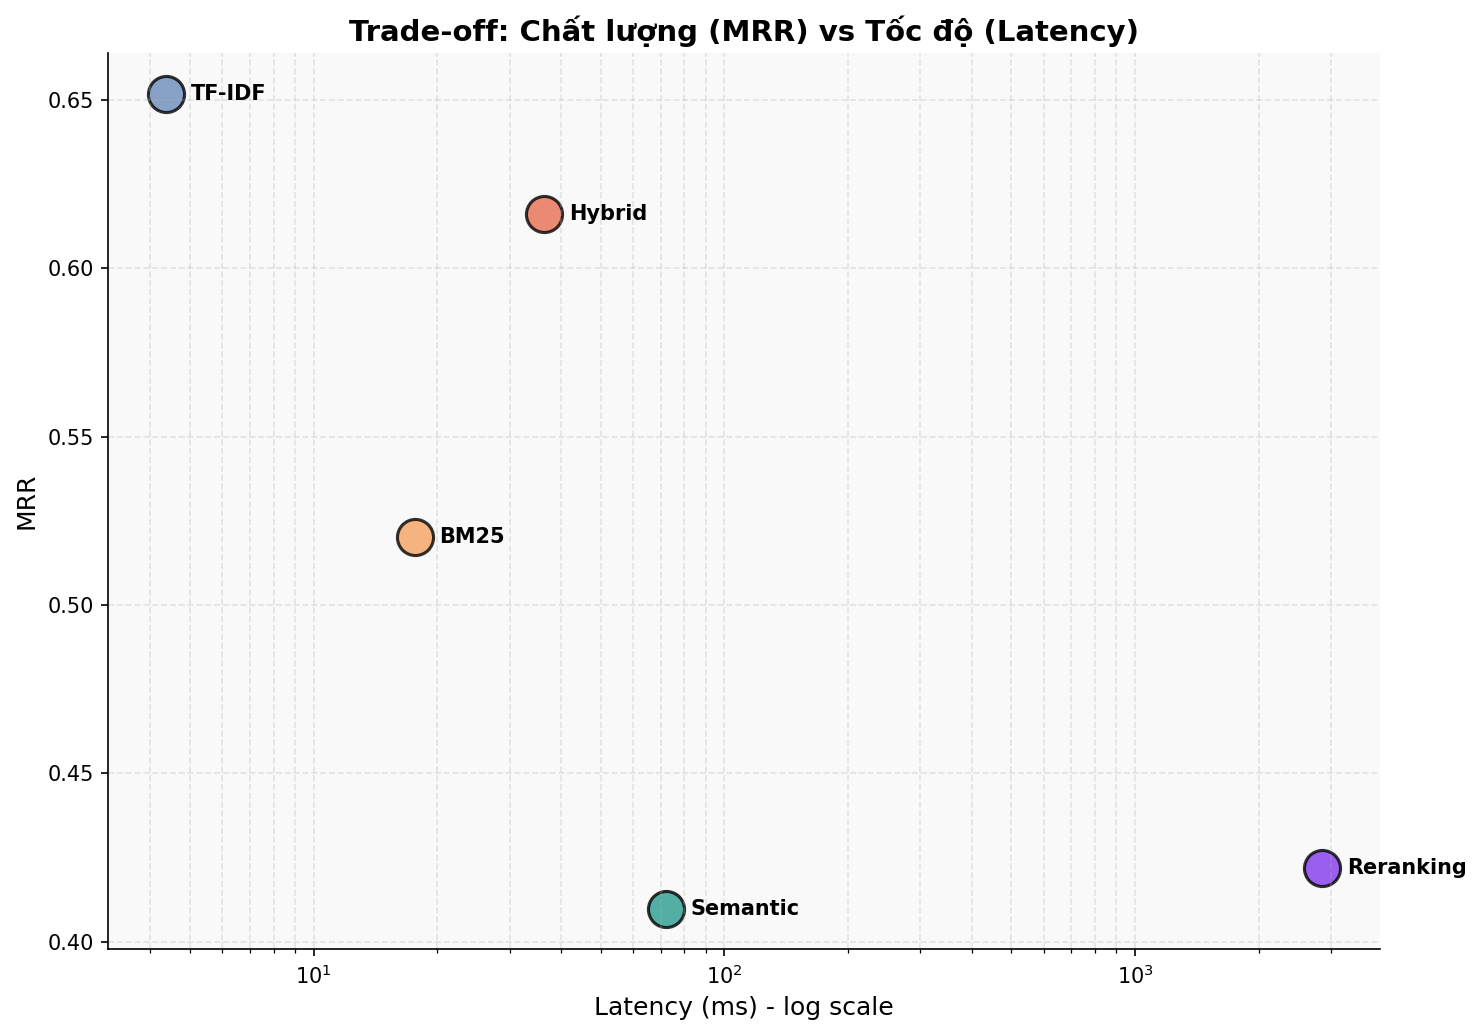

In [15]:
# 2. Biểu đồ đánh đổi giữa Độ trễ (Latency) và Chất lượng (MRR)
# Scatter plot giữa 2 chiều: tốc độ (trục X, log scale) vs chất lượng (trục Y)

plt.figure(figsize=(10, 7))
for model in summary_df.index:
    mrr_score = summary_df.loc[model, "MRR"]
    latency = summary_df.loc[model, "Latency (ms)"]
    
    plt.scatter(
        latency, 
        mrr_score, 
        color=MODEL_COLORS.get(model, '#000000'), 
        s=300, 
        label=model, 
        alpha=0.8,
        edgecolors='black',
        linewidth=1.5
    )
    
    # Thêm label cho mỗi điểm
    plt.text(
        latency * 1.15, 
        mrr_score, 
        model, 
        fontsize=10, 
        weight='bold',
        verticalalignment='center'
    )

plt.title("Trade-off: Chất lượng (MRR) vs Tốc độ (Latency)", fontsize=14, fontweight='bold')
plt.xlabel("Latency (ms) - log scale", fontsize=12)
plt.xscale("log")
plt.ylabel("MRR", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_PATH / 'eval_latency_quality.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: {FIGURE_PATH / 'eval_latency_quality.png'}")
plt.show()

## 7. Lưu báo cáo JSON tổng hợp

In [16]:
# Lưu báo cáo tóm tắt dưới dạng JSON
# Định dạng: { "retriever_name": {metrics...}, "_meta": {...} }

final_report = {
    'results': results_dict,
    '_meta': {
        'eval_top_k': eval_summary.eval_top_k,
        'num_qrels': eval_summary.num_qrels,
        'created_at': eval_summary.created_at.isoformat(),
        'num_models': len(summary_df),
    }
}

output_path = REPORT_PATH / 'evaluation_final.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(final_report, f, indent=2)

print(f"✓ Saved final report JSON to: {output_path}")
print()
print("="*80)
print("EVALUATION PIPELINE COMPLETE")
print("="*80)
print(f"✓ Evaluation results: {Path(settings.eval_output_path) / 'evaluation_results.json'}")
print(f"✓ Summary report: {output_path}")
print(f"✓ Figures: {FIGURE_PATH / 'eval_precision_bar.png'}")
print(f"✓ Figures: {FIGURE_PATH / 'eval_latency_quality.png'}")

✓ Saved final report JSON to: reports/evaluation_final.json

EVALUATION PIPELINE COMPLETE
✓ Evaluation results: data/eval/evaluation_results.json
✓ Summary report: reports/evaluation_final.json
✓ Figures: reports/figures/eval_precision_bar.png
✓ Figures: reports/figures/eval_latency_quality.png


In [17]:
print("Loading dataset using modular loader...")
df = load_dataframe(settings)
print(f"✓ Books loaded: {len(df):,}")

qrels_path = Path(settings.eval_output_path) / "qrels_short_only.json"
qrels = load_qrels(qrels_path)
print(f"✓ Test queries loaded from qrels: {len(qrels)}")

Loading dataset using modular loader...
✓ Books loaded: 500
✓ Test queries loaded from qrels: 58


In [18]:
settings.tfidf_model_path = Path('models/tfidf_vectorizer.pkl')
settings.bm25_index_path = Path('models/bm25_index.pkl')

print("Loading TF-IDF...")
tfidf = TFIDFRetriever.load(
    model_path=Path(settings.tfidf_model_path),
    matrix_path=Path(settings.tfidf_matrix_path),
    df=df,
)

print("Loading BM25...")
bm25 = BM25Retriever.load(
    index_path=Path(settings.bm25_index_path),
    df=df,
)

print("Loading Dense (ChromaDB)...")
dense = DenseRetriever.load(
    chroma_path=Path(settings.chroma_path),
    embedding_model=settings.embedding_model,
    collection_name=settings.chroma_collection_name,
)

print("Loading Hybrid RRF...")
hybrid = HybridRRFRetriever(
    bm25_retriever=bm25,
    dense_retriever=dense,
    candidate_pool=settings.hybrid_candidate_pool,
    rrf_k=settings.rrf_k,
)

print("Loading Reranker...")
rerank = RerankRetriever(
    dense_retriever=dense,
    rerank_model=settings.rerank_model,
    candidate_pool=settings.rerank_candidate_pool,
)

retrievers = {
    "TF-IDF": tfidf,
    "BM25": bm25,
    "Semantic": dense,
    "Hybrid": hybrid,
    "Reranking": rerank,
}
print("\nAll modular retrievers loaded successfully! ✓")

Loading TF-IDF...
Loading BM25...
Loading Dense (ChromaDB)...
Loading Hybrid RRF...
Loading Reranker...

All modular retrievers loaded successfully! ✓


In [19]:
# Khởi tạo evaluator với đầy đủ các tham số bắt buộc
# Evaluator.__init__ yêu cầu 3 tham số:
#   1. retrievers (dict): mapping tên retriever -> instance BaseRetriever
#   2. qrels (list): list các QrelItem (ground-truth relevance judgments)
#   3. settings: cấu hình ứng dụng chứa eval_top_k, eval_output_path, etc.

print("Khởi tạo Evaluator với các retrievers, qrels, và settings...")
evaluator = Evaluator(retrievers=retrievers, qrels=qrels, settings=settings)

print("Bắt đầu đánh giá các retrievers...")
print("Đánh giá sẽ mất vài phút tùy vào kích thước dữ liệu và tốc độ hệ thống.")
print()

# Chạy evaluator trên tất cả các retrievers cùng một lúc
# Evaluator.run() thực hiện:
#   1. Loop qua từng retriever trong self._retrievers
#   2. Với mỗi retriever, loop qua từng query trong qrels
#   3. Chạy retriever.search(query, top_k)
#   4. Tính toán IR metrics (P@5, P@10, R@5, R@10, MRR, NDCG@10, MAP)
#   5. Macro-average metrics qua tất cả queries
#   6. Lưu results tới evaluation_results.json
#
# Trả về: EvalSummary chứa results[retriever_name] = BenchmarkResult per retriever

eval_summary = evaluator.run()

print()
print("✓ Đánh giá hoàn thành!")
print(f"✓ Evaluation results lưu tại: {Path(settings.eval_output_path) / 'evaluation_results.json'}")

Khởi tạo Evaluator với các retrievers, qrels, và settings...
Bắt đầu đánh giá các retrievers...
Đánh giá sẽ mất vài phút tùy vào kích thước dữ liệu và tốc độ hệ thống.



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


✓ Đánh giá hoàn thành!
✓ Evaluation results lưu tại: data/eval/evaluation_results.json


In [20]:
# Trích xuất kết quả từ EvalSummary
# eval_summary.results là dict[str, BenchmarkResult]
# Mỗi BenchmarkResult chứa:
#   - retriever_name, precision_at_5, precision_at_10, recall_at_5, recall_at_10
#   - mrr, ndcg_at_10, map_score, num_queries, latency_ms

results_dict = {}
for retriever_name, benchmark_result in eval_summary.results.items():
    results_dict[retriever_name] = {
        "P@5": benchmark_result.precision_at_5,
        "P@10": benchmark_result.precision_at_10,
        "R@5": benchmark_result.recall_at_5,
        "R@10": benchmark_result.recall_at_10,
        "MRR": benchmark_result.mrr,
        "NDCG@10": benchmark_result.ndcg_at_10,
        "MAP": benchmark_result.map_score,
        "Latency (ms)": benchmark_result.latency_ms,
    }

# Tạo DataFrame so sánh kết quả
summary_df = pd.DataFrame(results_dict).T
summary_df.index.name = "Model"

print("\n" + "="*80)
print("FINAL EVALUATION RESULTS SUMMARY")
print("="*80)
display(summary_df)

# In ra thống kê tóm tắt
print("\nTop performers:")
print(f"Highest MRR: {summary_df['MRR'].idxmax()} ({summary_df['MRR'].max():.4f})")
print(f"Highest NDCG@10: {summary_df['NDCG@10'].idxmax()} ({summary_df['NDCG@10'].max():.4f})")
print(f"Highest MAP: {summary_df['MAP'].idxmax()} ({summary_df['MAP'].max():.4f})")
print(f"Fastest Latency: {summary_df['Latency (ms)'].idxmin()} ({summary_df['Latency (ms)'].min():.2f} ms)")


FINAL EVALUATION RESULTS SUMMARY


,P@5,P@10,R@5,R@10,MRR,NDCG@10,MAP,Latency (ms)
Model,,,,,,,,
TF-IDF,0.096552,0.082759,0.142870,0.189703,0.367022,0.193932,0.119024,5.436886
BM25,0.096552,0.087931,0.141846,0.171792,0.327456,0.180320,0.106256,4.930896
Semantic,0.041379,0.025862,0.100893,0.115740,0.149897,0.106818,0.087171,126.707912
Hybrid,0.103448,0.067241,0.146246,0.159526,0.355460,0.184768,0.128069,24.002338
Reranking,0.034483,0.022414,0.104748,0.110352,0.147886,0.101652,0.082522,2958.652934



Top performers:
Highest MRR: TF-IDF (0.3670)
Highest NDCG@10: TF-IDF (0.1939)
Highest MAP: Hybrid (0.1281)
Fastest Latency: BM25 (4.93 ms)


✓ Saved: reports/figures/eval_precision_bar.png


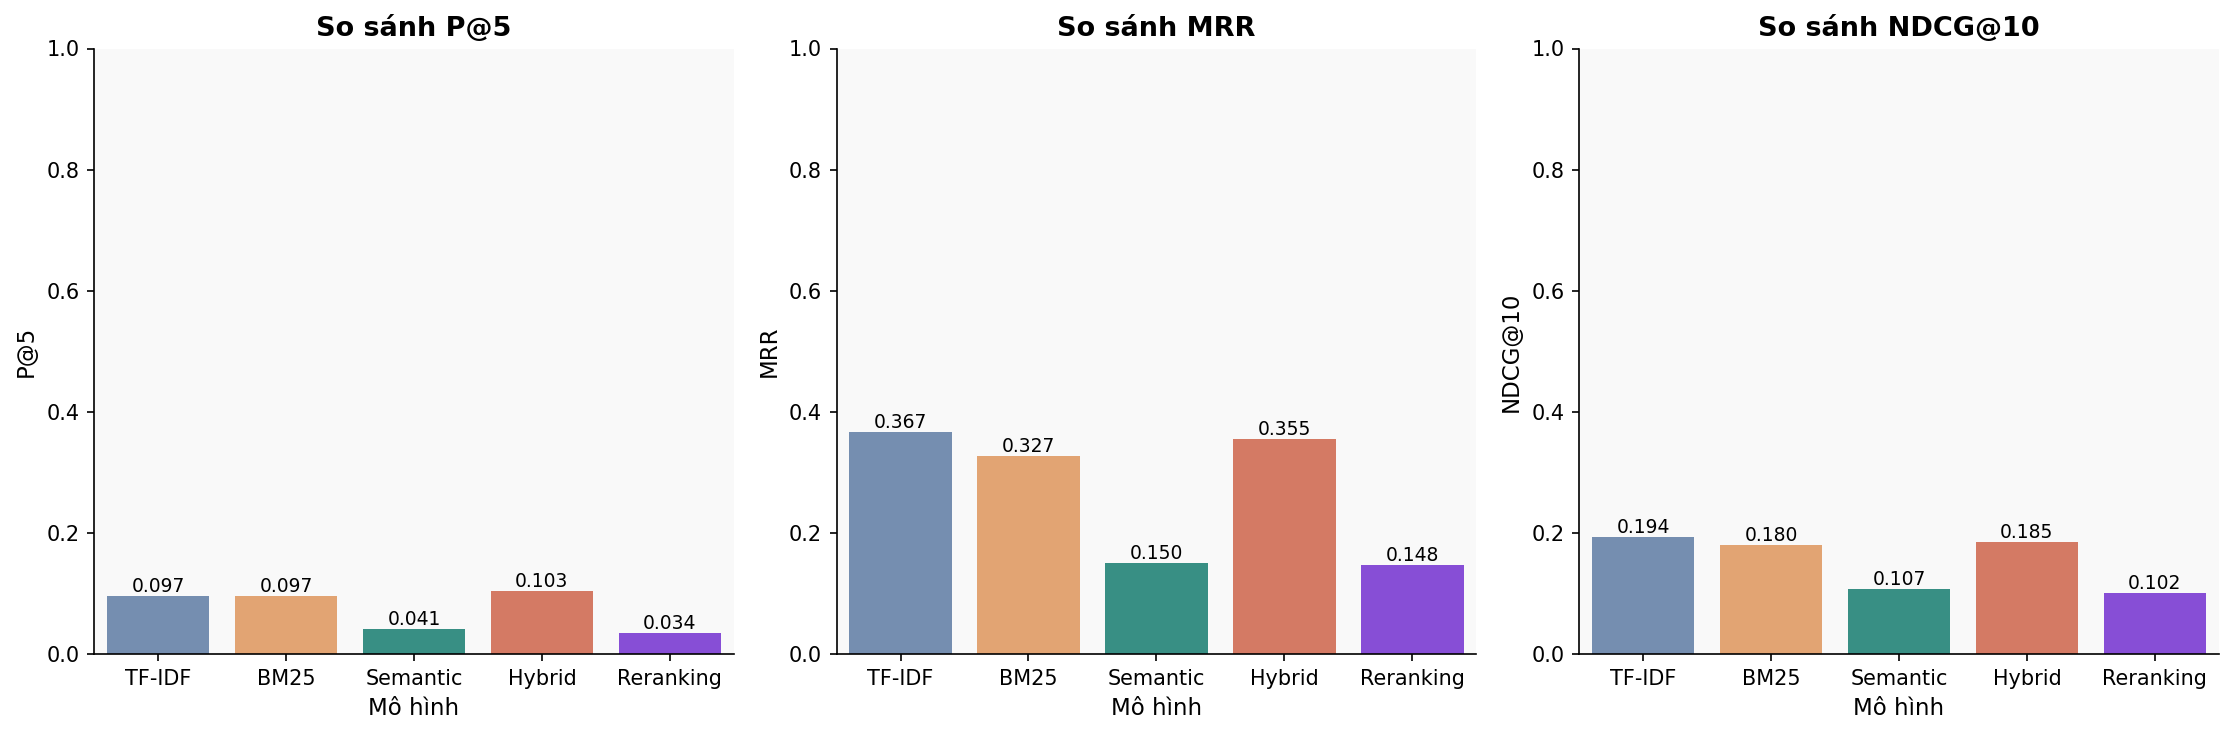

In [21]:
# 1. Biểu đồ so sánh Precision@5, MRR, và NDCG@10 giữa các mô hình
metrics_to_plot = ["P@5", "MRR", "NDCG@10"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(metrics_to_plot):
    colors = [MODEL_COLORS.get(model, "#CCCCCC") for model in summary_df.index]
    sns.barplot(
        x=summary_df.index, 
        y=summary_df[metric], 
        palette=colors, 
        ax=axes[i], 
        hue=summary_df.index, 
        legend=False
    )
    axes[i].set_title(f"So sánh {metric}", fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel("Mô hình")
    axes[i].set_ylim(0, 1.0)
    
    # Thêm giá trị trên mỗi cột
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'eval_precision_bar.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: {FIGURE_PATH / 'eval_precision_bar.png'}")
plt.show()

✓ Saved: reports/figures/eval_latency_quality.png


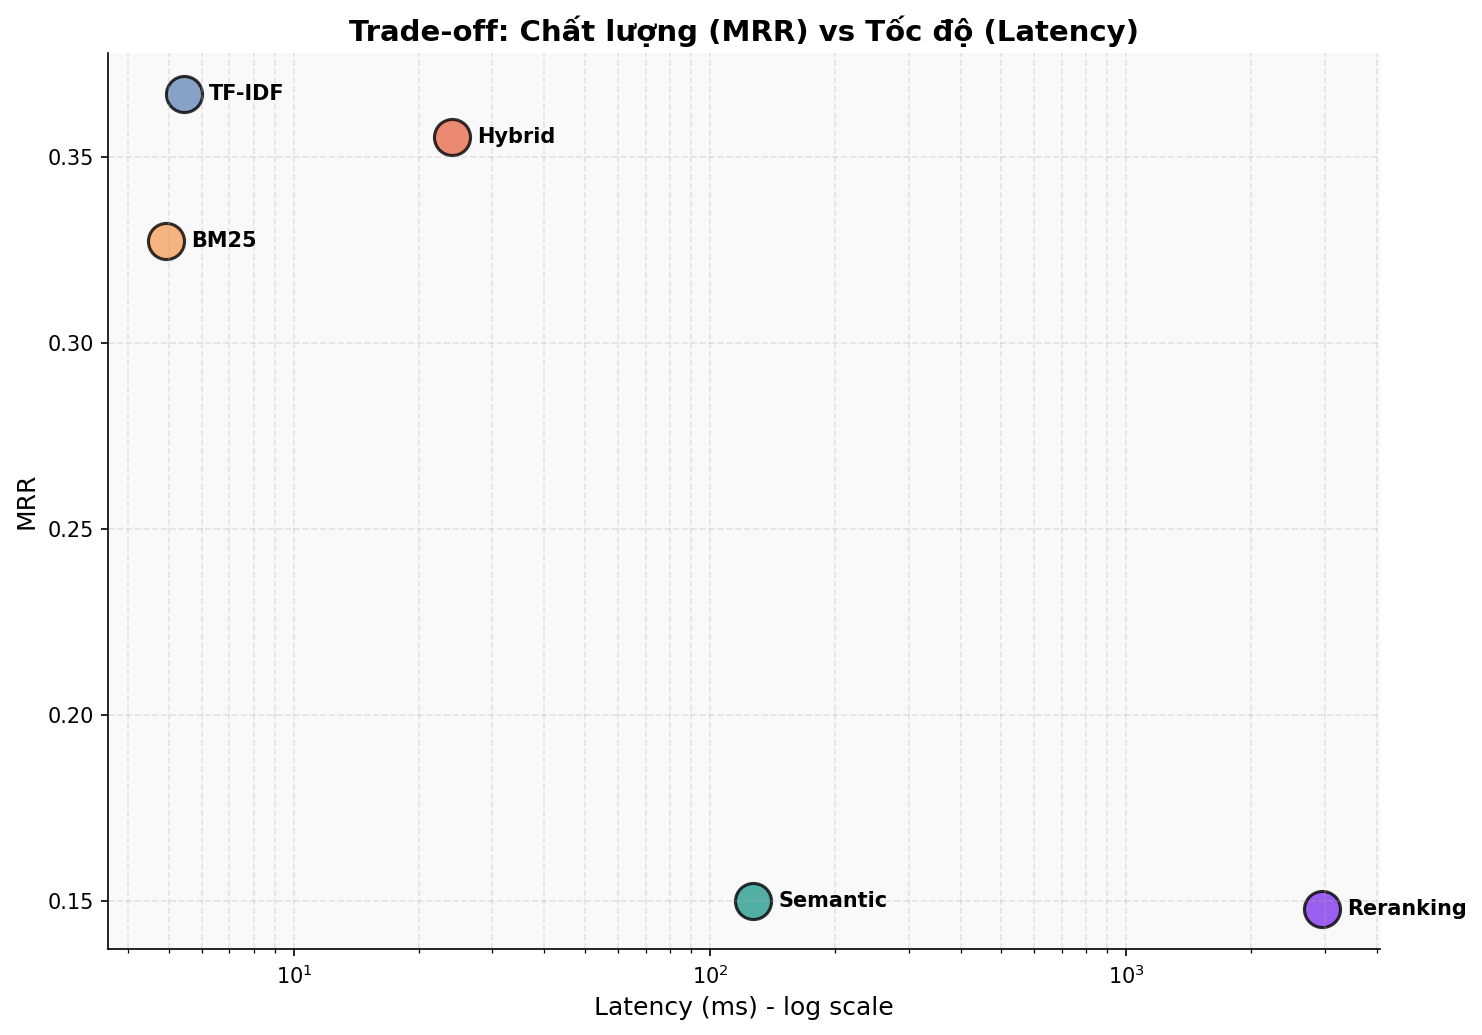

In [22]:
# 2. Biểu đồ đánh đổi giữa Độ trễ (Latency) và Chất lượng (MRR)
# Scatter plot giữa 2 chiều: tốc độ (trục X, log scale) vs chất lượng (trục Y)

plt.figure(figsize=(10, 7))
for model in summary_df.index:
    mrr_score = summary_df.loc[model, "MRR"]
    latency = summary_df.loc[model, "Latency (ms)"]
    
    plt.scatter(
        latency, 
        mrr_score, 
        color=MODEL_COLORS.get(model, '#000000'), 
        s=300, 
        label=model, 
        alpha=0.8,
        edgecolors='black',
        linewidth=1.5
    )
    
    # Thêm label cho mỗi điểm
    plt.text(
        latency * 1.15, 
        mrr_score, 
        model, 
        fontsize=10, 
        weight='bold',
        verticalalignment='center'
    )

plt.title("Trade-off: Chất lượng (MRR) vs Tốc độ (Latency)", fontsize=14, fontweight='bold')
plt.xlabel("Latency (ms) - log scale", fontsize=12)
plt.xscale("log")
plt.ylabel("MRR", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_PATH / 'eval_latency_quality.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: {FIGURE_PATH / 'eval_latency_quality.png'}")
plt.show()